<a href="https://colab.research.google.com/github/melissa-04/melisayla-biyoinformatik/blob/main/notebooks/scrna/06_adli_harita.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Adlandırılmış harita ve ortalamanın sakladığı

Serinin son analiz defteri. İki iş var: 2.5'te kurulan kimlikleri hücrelere işleyip haritayı hücre tipi adlarıyla boyamak, ve iki serinin buluşma noktasını sayıyla göstermek — bütün hücreleri tek bir "toplu örnek" gibi ortaladığımızda hangi sinyallerin kaybolduğunu ölçmek.

In [1]:
%pip install -q scanpy leidenalg igraph

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 31.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 70.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.7/5.7 MB 73.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 188.8/188.8 kB 11.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.0/40.0 kB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 73.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.1/79.1 kB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.7/363.7 kB 18.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 82.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.4/69.4 kB 5.2 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source o

## 1. Başlangıç durumu

Önceki rehberlerin tarifi tek hücrede; kümeleme resolution=0.5 ile.

In [2]:
import warnings; warnings.filterwarnings('ignore')
import urllib.request
import scanpy as sc
import numpy as np
import pandas as pd

urllib.request.urlretrieve('https://zenodo.org/records/22655336/files/pbmc3k_ders.h5ad?download=1', 'pbmc3k_ders.h5ad')
a = sc.read_h5ad('pbmc3k_ders.h5ad')
a.layers['sayim'] = a.X.copy()
sc.pp.normalize_total(a, target_sum=1e4)
sc.pp.log1p(a)
sc.pp.highly_variable_genes(a, flavor='seurat', min_mean=0.0125, max_mean=3, min_disp=0.5)
a.raw = a
a = a[:, a.var.highly_variable].copy()
sc.pp.scale(a, max_value=10)
sc.tl.pca(a, svd_solver='arpack', n_comps=50)
sc.pp.neighbors(a, n_neighbors=15, n_pcs=10)
sc.tl.leiden(a, resolution=0.5, key_added='leiden')
print('küme sayısı:', a.obs.leiden.nunique())

küme sayısı: 9


## 2. Adları işlemek

Küme numaralarını 2.5'teki eşlemeyle hücre tipi adlarına çeviriyoruz. `map`, obs'daki her küme numarasını listedeki karşılığıyla değiştirir; sonucu kategorik sütun olarak saklıyoruz. `sc.pl.umap(..., legend_loc='on data')` adları haritanın üstüne yazar.

hucre_tipi
CD4 T                   701
T (ribozomal-yüksek)    489
CD14+ monosit           426
B                       348
CD8/efektör T           311
FCGR3A+ monosit         223
NK                      147
Dendritik                36
Trombosit                13
Name: count, dtype: int64


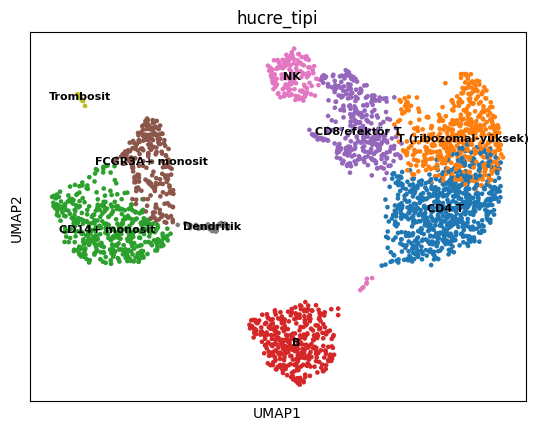

In [3]:
kume_adlari = ['CD4 T', 'T (ribozomal-yüksek)', 'CD14+ monosit', 'B', 'CD8/efektör T',
               'FCGR3A+ monosit', 'NK', 'Dendritik', 'Trombosit']
a.obs['hucre_tipi'] = a.obs.leiden.map({str(i): ad for i, ad in enumerate(kume_adlari)}).astype('category')
print(a.obs.hucre_tipi.value_counts())

sc.tl.umap(a)
sc.pl.umap(a, color='hucre_tipi', legend_loc='on data', legend_fontsize=8)

## 3. Ortalamanın sakladığı

Birinci serinin kapanış sorusu şuydu: toplu (bulk) ortalama bizden ne saklar? Artık ölçebiliriz. `a.raw.to_adata()` tam log-normalize matrisi geri verir; `np.expm1` log1p'nin tersini alıp değerleri CP10K ölçeğine döndürür. Sonra iki ortalama karşılaştırıyoruz: genin bütün 2.694 hücredeki ortalaması — bir bulk deneyin göreceği tek sayı — ve aynı genin kendi hücre tipindeki ortalaması.

In [4]:
tam = a.raw.to_adata()
ifade = pd.DataFrame(np.expm1(tam.X.toarray()), index=tam.obs_names, columns=tam.var_names)
ifade['tip'] = a.obs['hucre_tipi'].values

for gen in ['MS4A1', 'CD8A', 'LYZ', 'PPBP']:
    ort = ifade[gen].mean()
    grup = ifade.groupby('tip', observed=True)[gen].mean().sort_values(ascending=False)
    print(f'{gen}: tüm hücre ortalaması {ort:.1f} | {grup.index[0]} içinde {grup.iloc[0]:.1f} ({grup.iloc[0]/ort:.0f} kat)')

MS4A1: tüm hücre ortalaması 1.7 | B içinde 11.9 (7 kat)
CD8A: tüm hücre ortalaması 0.9 | CD8/efektör T içinde 4.2 (5 kat)
LYZ: tüm hücre ortalaması 38.8 | CD14+ monosit içinde 183.3 (5 kat)
PPBP: tüm hücre ortalaması 2.5 | Trombosit içinde 465.7 (188 kat)


## Kendin dene

Üç görev. Birincisi: dört genin "tüm hücre ortalaması / kendi tipindeki ortalama" değerlerini ve katlarını kendi koşunuzdan not edin. İkincisi, tek cümle: en büyük katı veren genin bu sonucu, birinci serinin "ortalama neyi saklar" sorusuna nasıl cevap veriyor? Üçüncüsü: koştuğunuz defteri indirip gönderin; serinin kapanış yazısı sizin bu sayılarınızla yazılacak.